<a href="https://colab.research.google.com/github/CodeWithradhika/CSET343./blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
from google.colab import files

uploaded = files.upload()

Saving dermatology_database_1.csv.zip to dermatology_database_1.csv (1).zip


In [10]:
from google.colab import files
import zipfile
import os
import pandas as pd

# Upload the ZIP file
uploaded = files.upload()

# Get the actual uploaded filename
zip_file = list(uploaded.keys())[0]

print("Uploaded file:", zip_file)

# Extract the ZIP file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dermatology_data')

# Show extracted files
print("\nExtracted files:")
print(os.listdir('/content/dermatology_data'))

Saving dermatology_database_1.csv.zip to dermatology_database_1.csv (3).zip
Uploaded file: dermatology_database_1.csv (3).zip

Extracted files:
['__MACOSX', 'dermatology_database_1.csv']


In [11]:
# Find the CSV file automatically

csv_files = []

for root, dirs, files_list in os.walk('/content/dermatology_data'):
    for file in files_list:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
print(csv_files)

CSV files found:
['/content/dermatology_data/dermatology_database_1.csv', '/content/dermatology_data/__MACOSX/._dermatology_database_1.csv']


In [12]:
# Load the first CSV file found

csv_path = csv_files[0]

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 366
Columns: 35

Column names:
['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate', 'age', 'class']


In [14]:
print("MEAN")
print(df.mean(numeric_only=True))

MEAN
erythema                               2.068306
scaling                                1.795082
definite_borders                       1.549180
itching                                1.366120
koebner_phenomenon                     0.633880
polygonal_papules                      0.448087
follicular_papules                     0.166667
oral_mucosal_involvement               0.377049
knee_and_elbow_involvement             0.614754
scalp_involvement                      0.519126
family_history                         0.125683
melanin_incontinence                   0.404372
eosinophils_infiltrate                 0.139344
PNL_infiltrate                         0.546448
fibrosis_papillary_dermis              0.336066
exocytosis                             1.368852
acanthosis                             1.956284
hyperkeratosis                         0.527322
parakeratosis                          1.289617
clubbing_rete_ridges                   0.663934
elongation_rete_ridges             

In [15]:
print("MEDIAN")
print(df.median(numeric_only=True))

MEDIAN
erythema                               2.0
scaling                                2.0
definite_borders                       2.0
itching                                1.0
koebner_phenomenon                     0.0
polygonal_papules                      0.0
follicular_papules                     0.0
oral_mucosal_involvement               0.0
knee_and_elbow_involvement             0.0
scalp_involvement                      0.0
family_history                         0.0
melanin_incontinence                   0.0
eosinophils_infiltrate                 0.0
PNL_infiltrate                         0.0
fibrosis_papillary_dermis              0.0
exocytosis                             2.0
acanthosis                             2.0
hyperkeratosis                         0.0
parakeratosis                          1.0
clubbing_rete_ridges                   0.0
elongation_rete_ridges                 0.0
thinning_suprapapillary_epidermis      0.0
spongiform_pustule                     0.0
munr

In [16]:
print("STANDARD DEVIATION")
print(df.std(numeric_only=True))

STANDARD DEVIATION
erythema                               0.664753
scaling                                0.701527
definite_borders                       0.907525
itching                                1.138299
koebner_phenomenon                     0.908016
polygonal_papules                      0.957327
follicular_papules                     0.570588
oral_mucosal_involvement               0.834147
knee_and_elbow_involvement             0.982979
scalp_involvement                      0.905639
family_history                         0.331946
melanin_incontinence                   0.869818
eosinophils_infiltrate                 0.411790
PNL_infiltrate                         0.815451
fibrosis_papillary_dermis              0.853139
exocytosis                             1.104418
acanthosis                             0.712512
hyperkeratosis                         0.757116
parakeratosis                          0.917562
clubbing_rete_ridges                   1.056829
elongation_rete_ridge

In [17]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess         

In [18]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [19]:
# Replace missing values with median

for column in df.columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].median()
        )

print("Missing values after handling:")
print(df.isnull().sum().sum())

Missing values after handling:
0


In [20]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [21]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(366, 35)


In [22]:
print(df.dtypes)

erythema                                int64
scaling                                 int64
definite_borders                        int64
itching                                 int64
koebner_phenomenon                      int64
polygonal_papules                       int64
follicular_papules                      int64
oral_mucosal_involvement                int64
knee_and_elbow_involvement              int64
scalp_involvement                       int64
family_history                          int64
melanin_incontinence                    int64
eosinophils_infiltrate                  int64
PNL_infiltrate                          int64
fibrosis_papillary_dermis               int64
exocytosis                              int64
acanthosis                              int64
hyperkeratosis                          int64
parakeratosis                           int64
clubbing_rete_ridges                    int64
elongation_rete_ridges                  int64
thinning_suprapapillary_epidermis 

In [23]:
print(df['class'].value_counts().sort_index())

class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


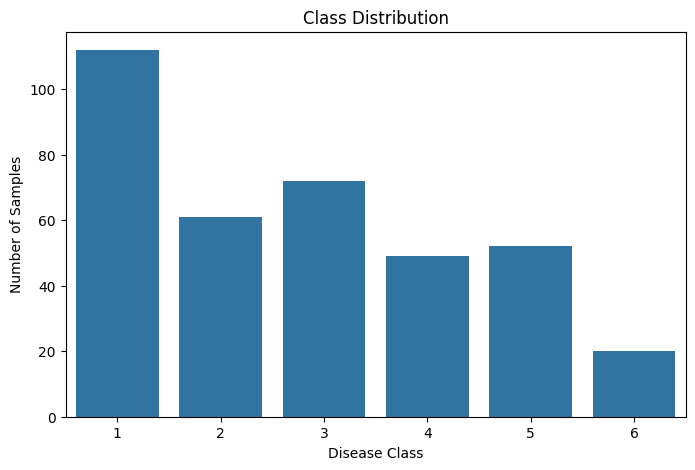

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='class'
)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

In [25]:
class_percentage = (
    df['class']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(class_percentage)

class
1    30.601093
2    16.666667
3    19.672131
4    13.387978
5    14.207650
6     5.464481
Name: proportion, dtype: float64


In [26]:
class_table = pd.DataFrame({
    'Number of Samples': df['class'].value_counts().sort_index(),
    'Percentage': class_percentage
})

class_table

,Number of Samples,Percentage
class,,
1,112,30.601093
2,61,16.666667
3,72,19.672131
4,49,13.387978
5,52,14.207650
6,20,5.464481


In [29]:
# Convert all columns except target to numeric

feature_columns = df.drop('class', axis=1).columns

for column in feature_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors='coerce'
    )

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
erythema                                 int64
scaling                                  int64
definite_borders                         int64
itching                                  int64
koebner_phenomenon                       int64
polygonal_papules                        int64
follicular_papules                       int64
oral_mucosal_involvement                 int64
knee_and_elbow_involvement               int64
scalp_involvement                        int64
family_history                           int64
melanin_incontinence                     int64
eosinophils_infiltrate                   int64
PNL_infiltrate                           int64
fibrosis_papillary_dermis                int64
exocytosis                               int64
acanthosis                               int64
hyperkeratosis                           int64
parakeratosis                            int64
clubbing_rete_ridges                     int64
elongation_rete_ridges         

In [30]:
# Check missing values

print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess        

In [31]:
# ============================================
# OUTLIER DETECTION USING IQR
# ============================================

numeric_columns = df.select_dtypes(
    include=np.number
).drop(columns=['class'], errors='ignore').columns

outlier_count = {}

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_count[column] = count


outlier_df = pd.DataFrame(
    list(outlier_count.items()),
    columns=['Feature', 'Outlier Count']
)

outlier_df

,Feature,Outlier Count
0,erythema,151
1,scaling,0
2,definite_borders,0
3,itching,0
4,koebner_phenomenon,18
5,polygonal_papules,69
6,follicular_papules,33
7,oral_mucosal_involvement,67
8,knee_and_elbow_involvement,23
9,scalp_involvement,16


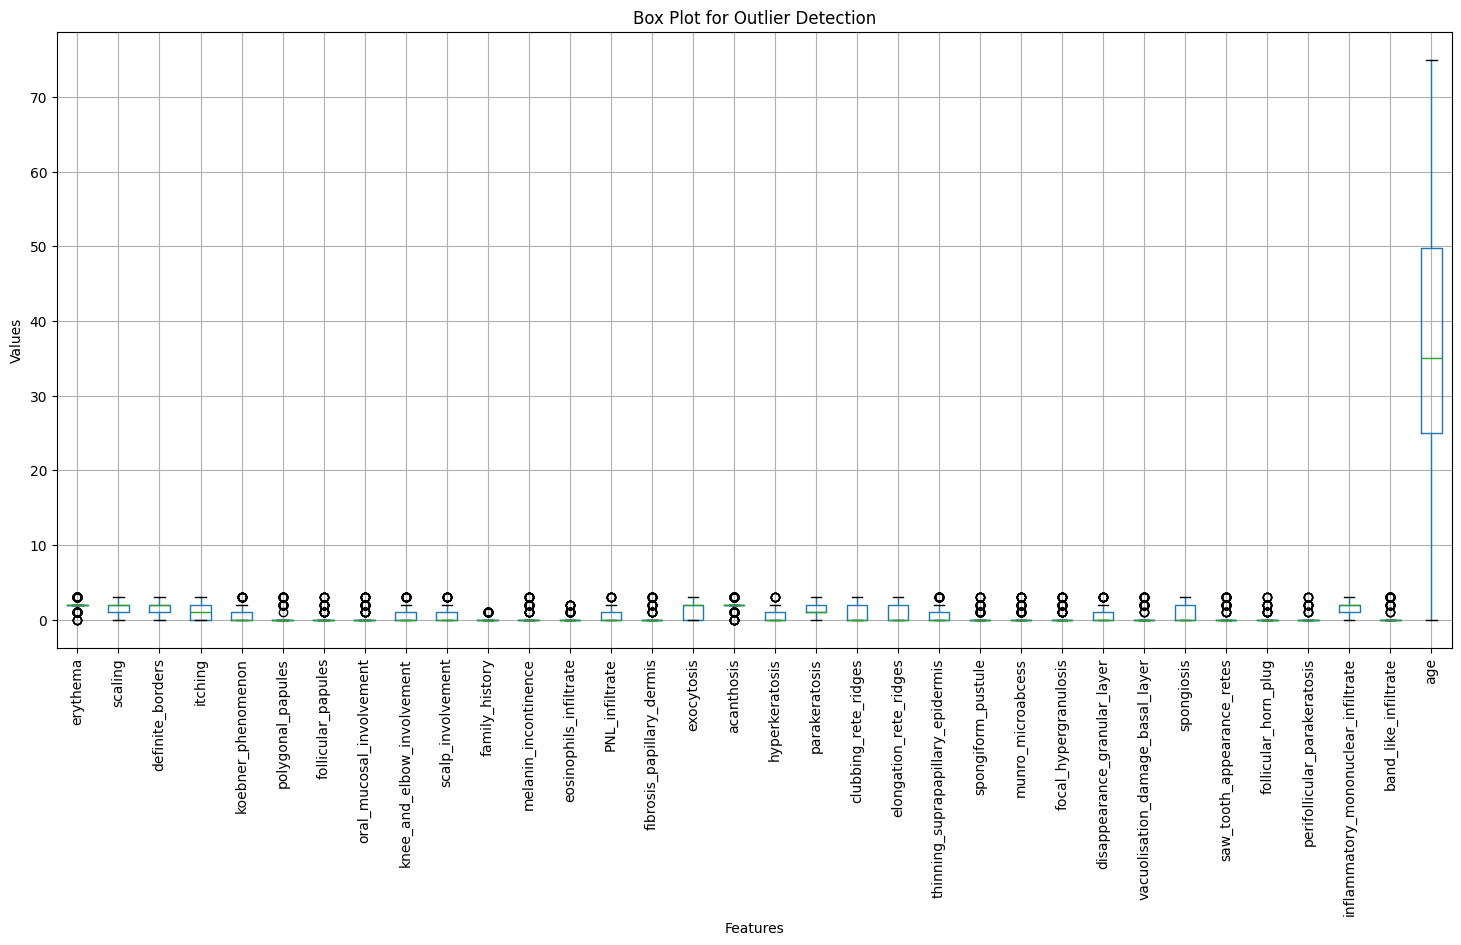

In [32]:
plt.figure(figsize=(18, 8))

df[numeric_columns].boxplot()

plt.title("Box Plot for Outlier Detection")

plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=90)

plt.show()

In [33]:

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower,
        upper=upper
    )

print("Outliers handled using IQR clipping.")

Outliers handled using IQR clipping.


In [34]:
print("Dataset shape:", df.shape)

print("Missing values:",
      df.isnull().sum().sum())

Dataset shape: (366, 35)
Missing values: 8


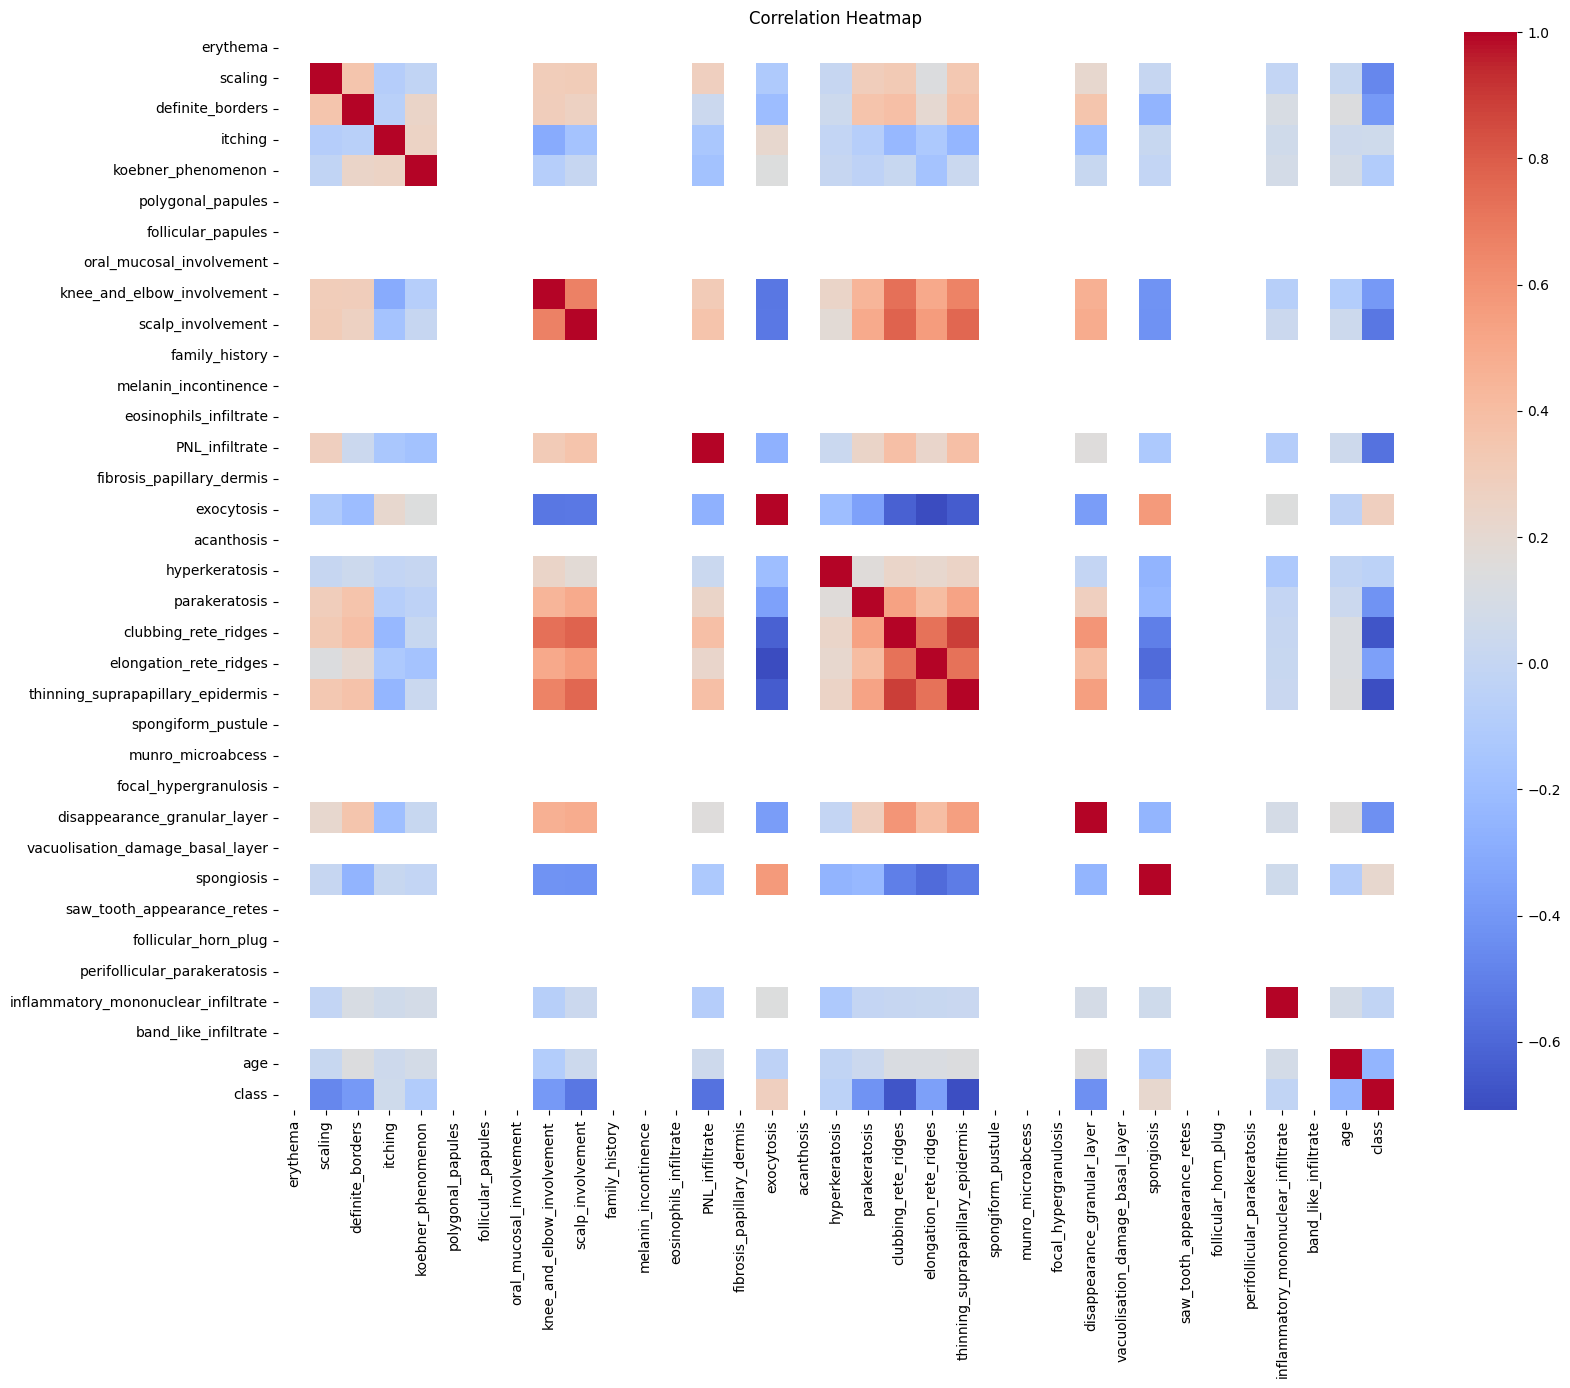

In [35]:
plt.figure(figsize=(18, 14))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

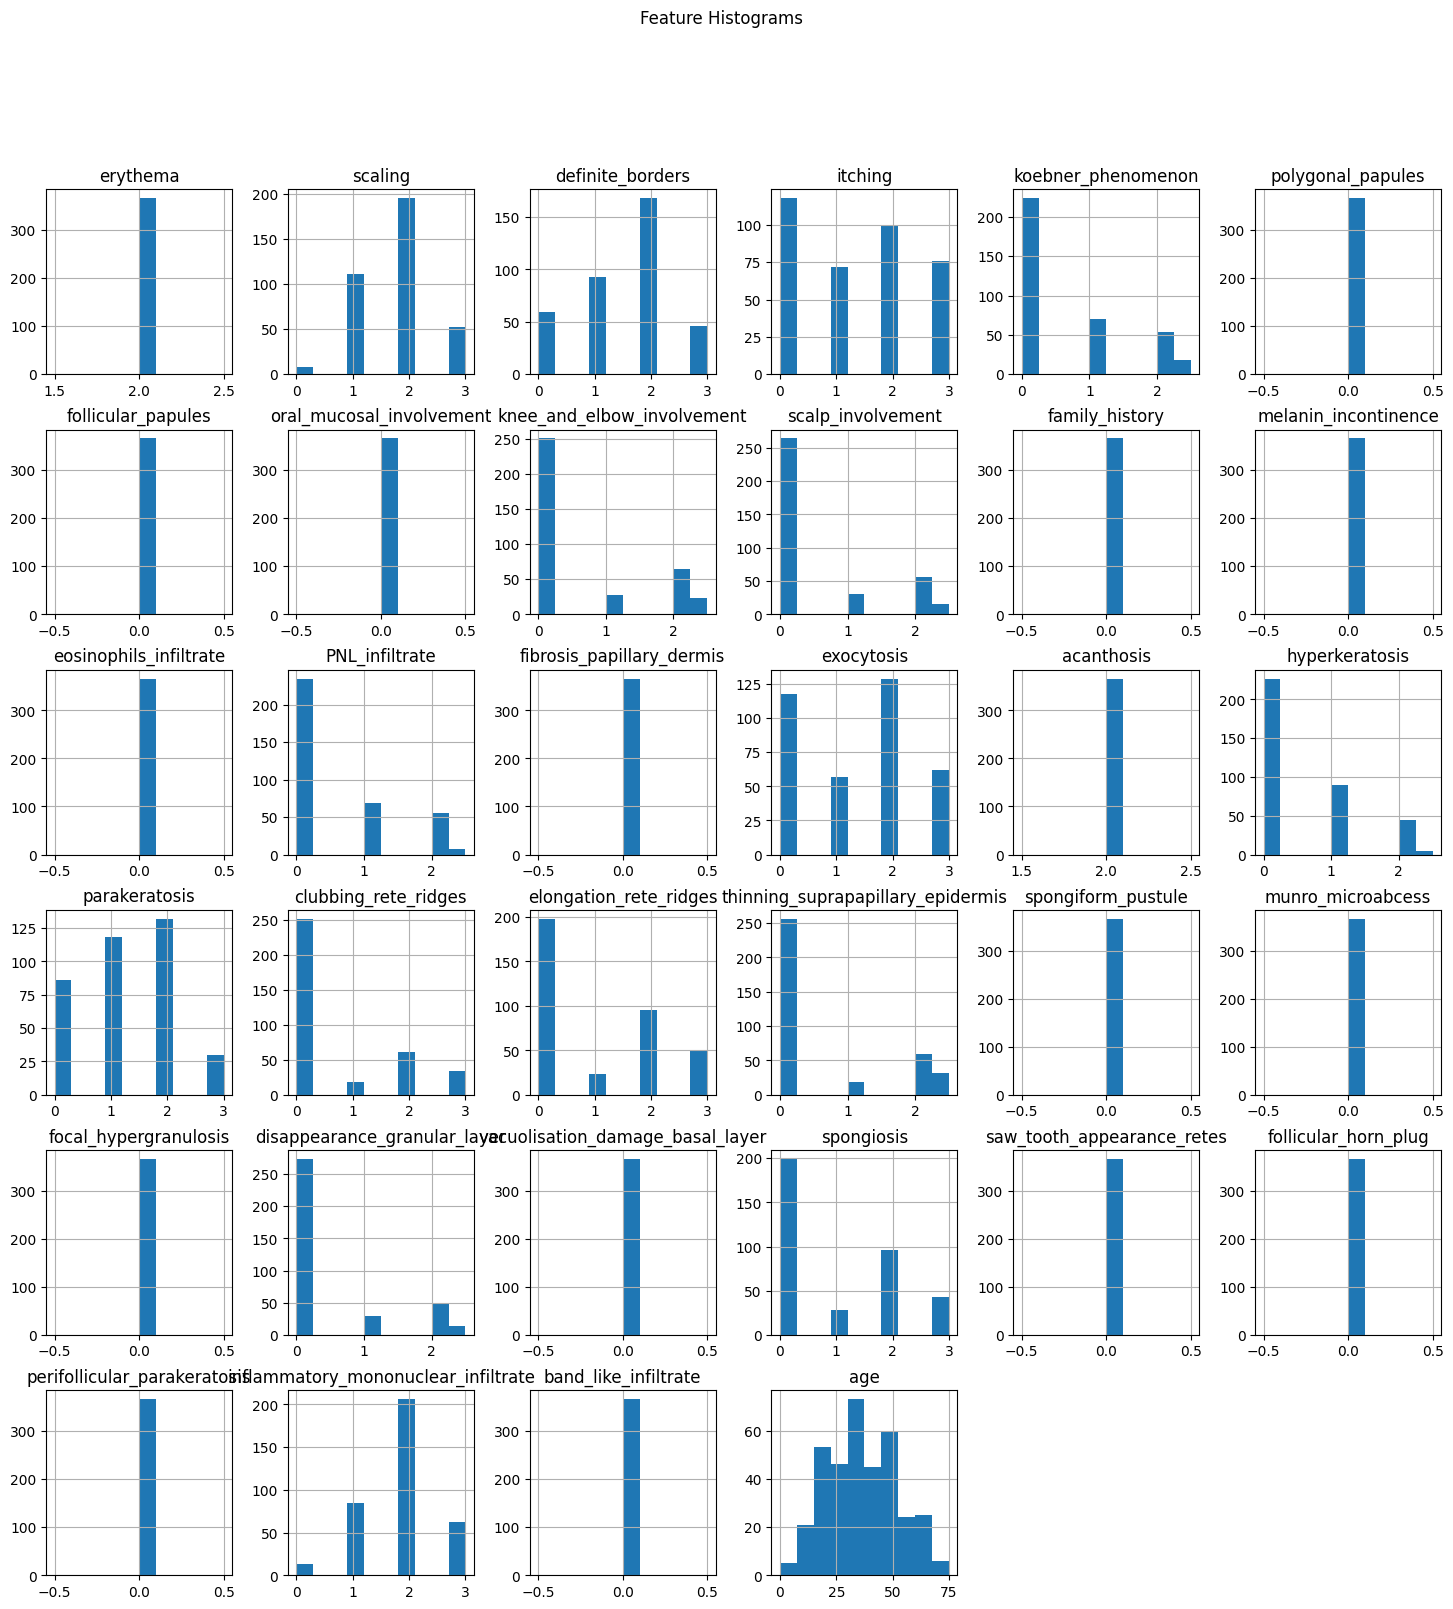

In [36]:
df.drop('class', axis=1).hist(
    figsize=(18, 18),
    bins=10
)

plt.suptitle("Feature Histograms")

plt.show()

In [37]:
X = df.drop('class', axis=1)

y = df['class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (366, 34)
y shape: (366,)


In [42]:
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

print("All models created!")

All models created!


In [44]:
# Separate features and target

X = df.drop('class', axis=1)
y = df['class']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("Missing values in y:")
print(y.isnull().sum())

X shape: (366, 34)
y shape: (366,)

Missing values in X:
8
Missing values in y:
0


In [45]:
# Convert all feature columns to numeric

X = X.apply(pd.to_numeric, errors='coerce')

print("Missing values after conversion:")
print(X.isnull().sum().sum())

Missing values after conversion:
8


In [46]:
from sklearn.impute import SimpleImputer

# Replace missing values with median

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)

print("Missing values after imputation:")
print(np.isnan(X_imputed).sum())

Missing values after imputation:
0


In [47]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:")
print(encoder.classes_)

print("Encoded classes:")
print(np.unique(y_encoded))

Classes:
[1 2 3 4 5 6]
Encoded classes:
[0 1 2 3 4 5]


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (292, 34)
Testing data: (74, 34)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardization completed!")

Standardization completed!


In [50]:
print("NaN in X_train:", np.isnan(X_train_scaled).sum())
print("NaN in X_test:", np.isnan(X_test_scaled).sum())

NaN in X_train: 0
NaN in X_test: 0


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

print("Models created successfully!")

Models created successfully!


In [52]:
trained_models = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model

    print(name, "trained successfully!")

KNN trained successfully!
Random Forest trained successfully!
Logistic Regression trained successfully!
SVM trained successfully!


In [53]:
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred

    print(name, "prediction completed!")

KNN prediction completed!
Random Forest prediction completed!
Logistic Regression prediction completed!
SVM prediction completed!


In [54]:


predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred

    print(name, "prediction completed!")

KNN prediction completed!
Random Forest prediction completed!
Logistic Regression prediction completed!
SVM prediction completed!


In [55]:


accuracy_results = {}

for name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_results[name] = accuracy

    print(
        name,
        "Accuracy =",
        round(accuracy, 4)
    )

KNN Accuracy = 0.9189
Random Forest Accuracy = 0.9189
Logistic Regression Accuracy = 0.9595
SVM Accuracy = 0.973


In [56]:
accuracy_df = pd.DataFrame(
    list(accuracy_results.items()),
    columns=['Model', 'Accuracy']
)

accuracy_df

,Model,Accuracy
0,KNN,0.918919
1,Random Forest,0.918919
2,Logistic Regression,0.959459
3,SVM,0.972973


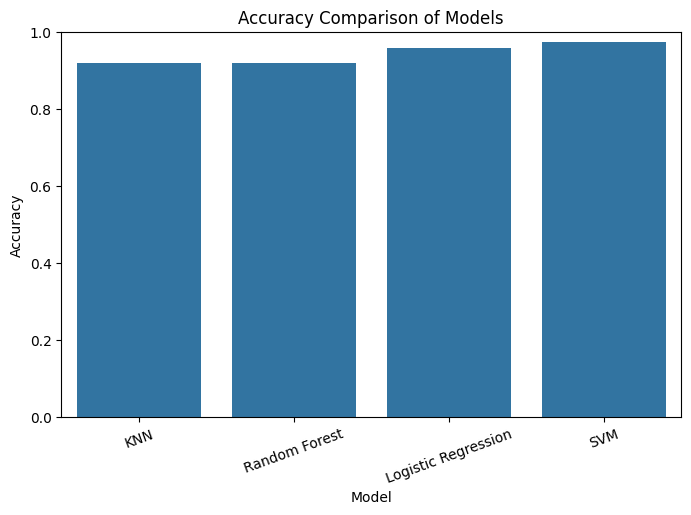

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=accuracy_df,
    x='Model',
    y='Accuracy'
)

plt.title("Accuracy Comparison of Models")

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

In [58]:


metric_results = []

for name, y_pred in predictions.items():

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    metric_results.append([
        name,
        precision,
        recall,
        f1
    ])


metrics_df = pd.DataFrame(
    metric_results,
    columns=[
        'Model',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

metrics_df

,Model,Precision,Recall,F1 Score
0,KNN,0.922099,0.918919,0.914112
1,Random Forest,0.922604,0.918919,0.919241
2,Logistic Regression,0.958803,0.959459,0.958611
3,SVM,0.972973,0.972973,0.972973


In [59]:

for name, y_pred in predictions.items():

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )



KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.88      0.58      0.70        12
           2       0.88      1.00      0.94        15
           3       0.75      0.90      0.82        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.92        74
   macro avg       0.92      0.91      0.91        74
weighted avg       0.92      0.92      0.91        74



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.75      0.75      0.75        12
           2       1.00      0.87      0.93        15
           3       0.82      0.90      0.86        10
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00         4

    accuracy                           0.92        74
 

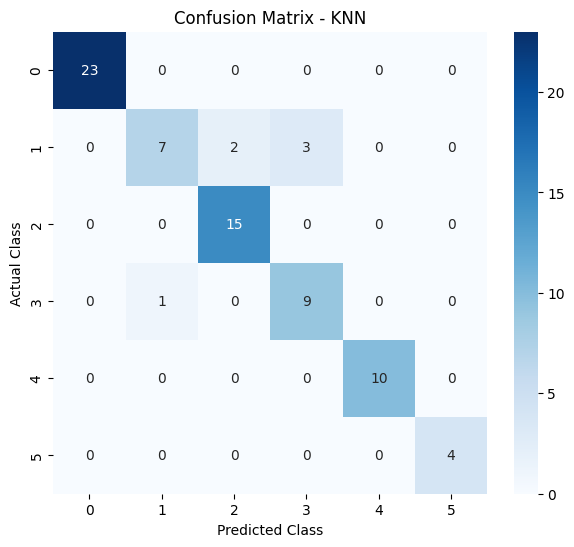

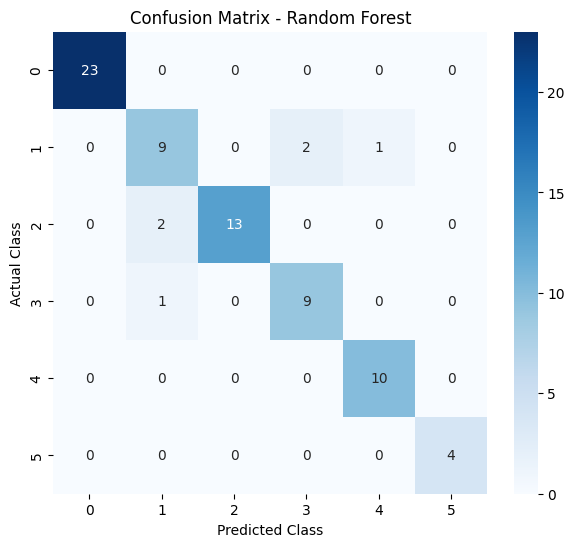

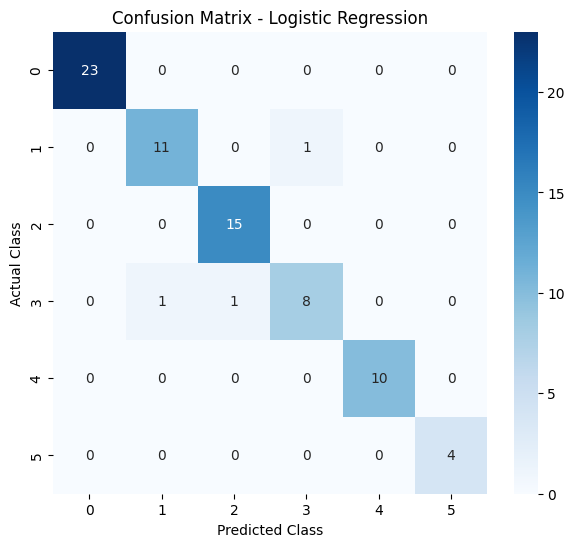

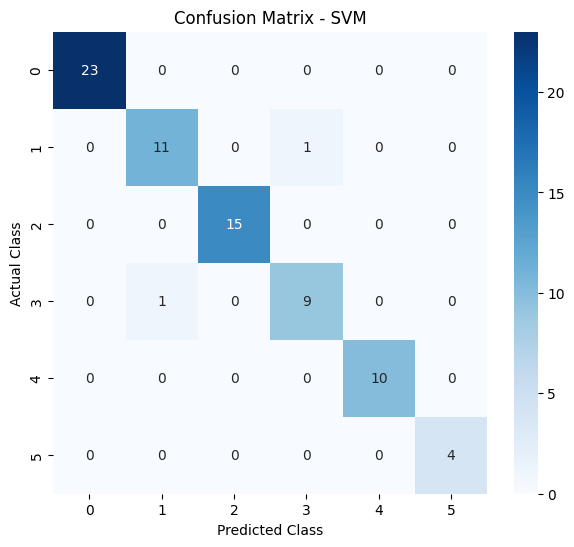

In [60]:


for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        "Confusion Matrix - " + name
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

In [61]:
print("Original class labels:")
print(encoder.classes_)

Original class labels:
[1 2 3 4 5 6]


In [62]:

n_classes = len(
    np.unique(y_encoded)
)

y_test_binary = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

print("Number of classes:", n_classes)
print("Binary target shape:", y_test_binary.shape)

Number of classes: 6
Binary target shape: (74, 6)


In [63]:

auc_results = {}

for name, model in trained_models.items():

    # Probability for each class
    y_score = model.predict_proba(
        X_test_scaled
    )

    auc_score = roc_auc_score(
        y_test_binary,
        y_score,
        multi_class='ovr',
        average='macro'
    )

    auc_results[name] = auc_score

    print(
        name,
        "AUC =",
        round(auc_score, 4)
    )

KNN AUC = 0.9814
Random Forest AUC = 0.9958
Logistic Regression AUC = 0.9975
SVM AUC = 0.9969


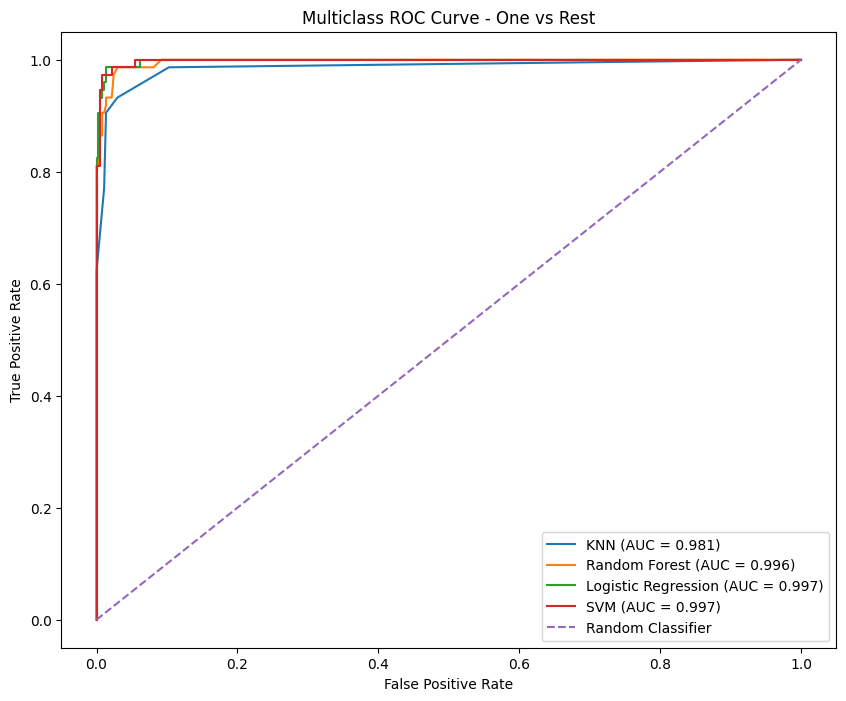

In [64]:

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():

    y_score = model.predict_proba(
        X_test_scaled
    )

    fpr, tpr, thresholds = roc_curve(
        y_test_binary.ravel(),
        y_score.ravel()
    )

    auc_score = auc_results[name]

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curve - One vs Rest"
)

plt.legend()

plt.show()

In [65]:


final_results = []

for name in trained_models.keys():

    y_pred = predictions[name]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    auc_score = auc_results[name]

    final_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ])


final_df = pd.DataFrame(
    final_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'AUC'
    ]
)

final_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,KNN,0.918919,0.922099,0.918919,0.914112,0.981371
1,Random Forest,0.918919,0.922604,0.918919,0.919241,0.995783
2,Logistic Regression,0.959459,0.958803,0.959459,0.958611,0.997462
3,SVM,0.972973,0.972973,0.972973,0.972973,0.996942


In [66]:
# Display results up to 4 decimal places

final_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,KNN,0.9189,0.9221,0.9189,0.9141,0.9814
1,Random Forest,0.9189,0.9226,0.9189,0.9192,0.9958
2,Logistic Regression,0.9595,0.9588,0.9595,0.9586,0.9975
3,SVM,0.9730,0.9730,0.9730,0.9730,0.9969


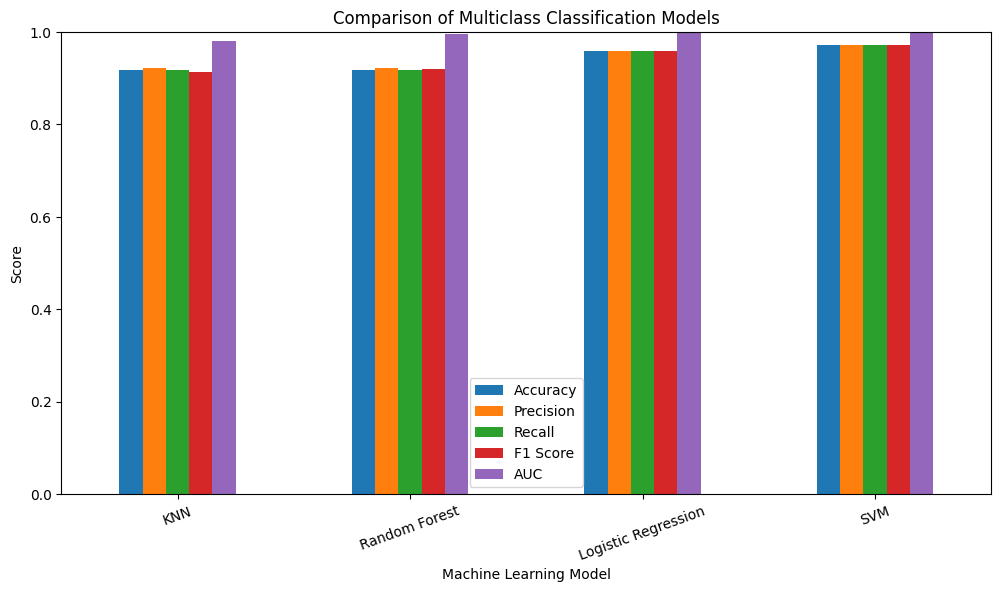

In [67]:

final_df.set_index(
    'Model'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'AUC'
    ]
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title(
    "Comparison of Multiclass Classification Models"
)

plt.xlabel("Machine Learning Model")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.legend()

plt.show()

In [68]:
print("\n")
print("=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

print(
    final_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)



FINAL MODEL PERFORMANCE
              Model  Accuracy  Precision  Recall  F1 Score    AUC
                KNN    0.9189     0.9221  0.9189    0.9141 0.9814
      Random Forest    0.9189     0.9226  0.9189    0.9192 0.9958
Logistic Regression    0.9595     0.9588  0.9595    0.9586 0.9975
                SVM    0.9730     0.9730  0.9730    0.9730 0.9969


In [69]:
final_df.to_csv(
    "Dermatology_Model_Results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
